In [71]:
import seaborn as sns
import pandas as pd
import matplotlib.pyplot as plt

In [72]:
nr_of_seeds = 30 #nr of seeds in the experiments

In [73]:
#Function that returns best params for each pair of (target_column, target_instance) 
# and their average val rmse, rmse, mae, given a set of config columns (depending on method)
# This funcion can take a dataframe or a path to a csv as input.
# the best settings are chosen using the lowest val rmse
def topk_per_d_per_method(data, config_cols, k=5):
    """
    Return up to the top-k configs per group, ranked by avg_rmse.
    Averages are computed across seeds.
    """
    df = pd.read_csv(data, index_col = [0]) if isinstance(data, str) else data.copy()
    df = df.sort_values(by = ['seed'])

    agg = (df.groupby(config_cols, as_index=False)
            .agg(avg_rmse=('rmse','mean'),
                avg_mae=('mae','mean'),
                n_seeds=('seed','nunique')))
    agg = agg.merge(df, how = 'right')
    agg = agg.sort_values(by = 'avg_rmse').head(k)
    topk_df = agg #agg.groupby(['seed'], group_keys=False).head(k)
    topk_d = topk_df[['avg_rmse', 'rmse', 'mae']]
    return topk_d, topk_df

In [74]:
# Define custom matplotlib colors by their index (only to get consistent colors with friedman vizes)
custom_colors = [plt.get_cmap("tab10")(i) for i in [0, 1, 2, 4]]

# Set this as the default Seaborn palette globally
sns.set_palette(custom_colors)

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\3226150917.py:12: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\3226150917.py:22: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\3226150917.py:32: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

<Axes: xlabel='method', ylabel='rmse'>

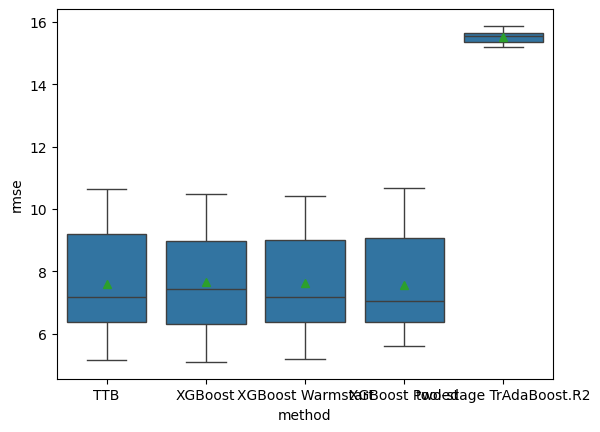

In [75]:
sub_name = 'location'

dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=nr_of_seeds
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/xgb_naive.csv')
xgboost_data_pooled = data
xgboost_data_pooled ['method'] = 'XGBoost Pooled'

best_XGBoost_pooled , best_XGBoost_params_pooled  = topk_per_d_per_method(
    xgboost_data_pooled ,
['v', 'target_tree_size'], k=nr_of_seeds
)
best_XGBoost_pooled['method'] = 'XGBoost Pooled'

data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
trada_data = data
trada_data['method'] = 'two-stage TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators'], k=nr_of_seeds
)
best_trada['method'] = 'two-stage TrAdaBoost.R2'



df = best_LSTransferTreeBoost
df = pd.concat([best_LSTransferTreeBoost, best_XGBoost])
df = pd.concat([df, best_XGBoost_warmstart])
df = pd.concat([df, best_XGBoost_pooled])
df = pd.concat([df, best_trada])
marker_dict = {
'TransferTreeBoost': 'o',
'XGBoost': '^',
}

linestyles_dict = {
    'LSTransferTreeBoost': '-',
    'XGBoost': '--', 
}
    
linestyles_dict=['-', '--']


sns.boxplot(
data=df,
x='method', y='rmse', showmeans = True)





In [76]:
#Obtain best parameters in order based on test rmse
dat = pd.read_csv(f'results_{sub_name}/ttb_LS.csv', index_col = [0])
dat = dat.reset_index(drop=True) 
dat['method'] = 'TransferTreeBoost'
dat = dat.sort_values(by = ['seed', 'v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'])

best_LSTransferTreeBoost, best_LSTransferTreeBoost_params = topk_per_d_per_method(
    dat,
['v', 'source_tree_size', 'target_tree_size', 'k', 'm_0'], k=100000
)
best_LSTransferTreeBoost['method'] = 'TTB'

data = pd.read_csv(f'results_{sub_name}/xgb.csv')
xgboost_data = data
xgboost_data['method'] = 'XGBoost'

best_XGBoost, best_XGBoost_params = topk_per_d_per_method(
    xgboost_data,
['v', 'target_tree_size'], k=100000
)
best_XGBoost['method'] = 'XGBoost'

data = pd.read_csv(f'results_{sub_name}/xgb_warmstart.csv')
xgboost_data_warmstart = data
xgboost_data_warmstart ['method'] = 'XGBoost Warmstart'

best_XGBoost_warmstart , best_XGBoost_params_warmstart  = topk_per_d_per_method(
    xgboost_data_warmstart ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_warmstart ['method'] = 'XGBoost Warmstart'

data = pd.read_csv(f'results_{sub_name}/xgb_naive.csv')
xgboost_data_pooled = data
xgboost_data_pooled ['method'] = 'XGBoost Pooled'

best_XGBoost_pooled , best_XGBoost_params_pooled  = topk_per_d_per_method(
    xgboost_data_pooled ,
['v', 'target_tree_size'], k=100000
)
best_XGBoost_pooled['method'] = 'XGBoost Pooled'

data = pd.read_csv(f'results_{sub_name}/two_trada.csv')
trada_data = data
trada_data['method'] = 'two-stage TrAdaBoost.R2'

best_trada, best_trada_params = topk_per_d_per_method(
    trada_data,
['lr', 'n_estimators'], k=100000
)
best_trada['method'] = 'two-stage TrAdaBoost.R2'

C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\4067341213.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_LSTransferTreeBoost['method'] = 'TTB'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\4067341213.py:21: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  best_XGBoost['method'] = 'XGBoost'
C:\Users\Dag Bjornberg\AppData\Local\Temp\ipykernel_13280\4067341213.py:31: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_ind

In [77]:
#Get best params in order
best_LSTransferTreeBoost_params.iloc[::nr_of_seeds]

,v,source_tree_size,target_tree_size,k,m_0,avg_rmse,avg_mae,n_seeds,seed,epochs,val_rmse,val_mae,rmse,mae,method
25,0.3,2.0,2.0,0.00,0.5,7.605026,5.266839,30,860.0,400.0,5.506253,4.286977,6.033586,4.781888,TransferTreeBoost
1563,0.2,2.0,2.0,0.00,0.5,7.640882,5.302736,30,881.0,400.0,7.298444,5.796340,6.699011,4.798384,TransferTreeBoost
1609,0.2,1.0,2.0,0.00,0.5,7.649546,5.297006,30,882.0,400.0,5.787510,4.455856,6.528609,5.182417,TransferTreeBoost
1413,0.1,2.0,2.0,0.00,0.5,7.679807,5.335602,30,879.0,400.0,9.254504,4.899721,8.698915,6.221901,TransferTreeBoost
1354,0.2,3.0,2.0,0.00,0.5,7.686378,5.380178,30,878.0,400.0,8.115233,5.628442,6.939034,5.436230,TransferTreeBoost
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2158,0.3,1.0,2.0,0.01,0.9,9.680554,7.329540,30,889.0,400.0,7.174875,5.018232,6.025072,4.410503,TransferTreeBoost
26,0.3,2.0,1.0,0.01,0.9,9.682208,7.596310,30,860.0,400.0,8.748281,7.260849,8.809083,7.894690,TransferTreeBoost
1359,0.3,1.0,1.0,0.01,0.9,9.780944,7.674787,30,878.0,400.0,12.408005,10.336469,11.656944,10.500469,TransferTreeBoost
93,0.1,1.0,2.0,0.01,0.9,9.793792,7.272413,30,861.0,400.0,7.529642,5.206451,5.823053,4.591509,TransferTreeBoost


In [78]:
#Get best params in order
best_XGBoost_params.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
1257,0.250,1.0,7.667327,5.296526,30,1288,876.0,5.561655,4.373795,9.541385,6.182238,XGBoost
345,0.200,1.0,7.676217,5.295813,30,350,864.0,7.543929,6.062942,7.834675,5.608219,XGBoost
640,0.225,1.0,7.677334,5.273855,30,665,868.0,6.669817,4.747303,8.794026,5.965609,XGBoost
18,0.150,1.0,7.684421,5.299788,30,28,860.0,5.466306,4.314261,5.794829,4.595219,XGBoost
176,0.125,1.0,7.693279,5.307179,30,175,862.0,7.423415,5.216718,9.771558,5.796854,XGBoost
...,...,...,...,...,...,...,...,...,...,...,...,...
401,0.300,7.0,8.333151,5.783879,30,461,865.0,10.417118,6.270694,6.226488,4.851451,XGBoost
271,0.150,7.0,8.334975,5.789308,30,265,863.0,6.569746,5.074320,10.703870,6.389772,XGBoost
1270,0.275,7.0,8.338920,5.808811,30,1301,876.0,6.956924,5.296039,9.985689,6.833802,XGBoost
2297,0.075,7.0,8.373951,5.804337,30,2246,889.0,8.037333,5.755734,6.358602,4.520801,XGBoost


In [79]:
#Get best params in order
best_XGBoost_params_warmstart.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
52,0.175,1.0,7.622802,5.228433,30,35,860.0,5.538168,4.301345,6.102843,4.941187,XGBoost Warmstart
1450,0.200,1.0,7.630576,5.249527,30,1428,878.0,8.073004,5.520975,6.467878,4.783600,XGBoost Warmstart
717,0.225,1.0,7.631062,5.240750,30,742,869.0,8.037803,5.744232,6.923205,5.086997,XGBoost Warmstart
886,0.150,1.0,7.634895,5.230074,30,875,871.0,7.171151,5.028286,5.982715,4.693389,XGBoost Warmstart
1429,0.275,1.0,7.639549,5.242325,30,1449,878.0,8.030327,5.493364,6.633027,4.773776,XGBoost Warmstart
...,...,...,...,...,...,...,...,...,...,...,...,...
1967,0.250,7.0,8.324891,5.820238,30,1987,885.0,7.911121,5.924056,10.751063,6.661288,XGBoost Warmstart
1039,0.300,7.0,8.380669,5.896905,30,1077,873.0,8.635426,5.707412,7.907644,5.909586,XGBoost Warmstart
1210,0.275,7.0,8.381025,5.830919,30,1224,875.0,6.001498,4.471548,7.934790,5.691294,XGBoost Warmstart
580,0.300,6.0,8.381614,5.824755,30,614,867.0,7.316213,4.858372,11.752222,7.408033,XGBoost Warmstart


In [80]:
best_XGBoost_params_pooled.iloc[::nr_of_seeds]

,v,target_tree_size,avg_rmse,avg_mae,n_seeds,Unnamed: 0,seed,val_rmse,val_mae,rmse,mae,method
927,0.275,3.0,7.579369,5.274467,30,989,872.0,6.805129,4.862311,9.361209,5.973960,XGBoost Pooled
386,0.200,3.0,7.620667,5.305270,30,429,865.0,9.783232,5.719819,5.403914,4.289293,XGBoost Pooled
607,0.175,3.0,7.621339,5.273161,30,576,867.0,6.546843,4.101781,10.729620,5.927649,XGBoost Pooled
197,0.300,3.0,7.631109,5.298789,30,226,862.0,7.408916,5.513525,10.188632,6.317012,XGBoost Pooled
1902,0.225,3.0,7.636359,5.298334,30,1899,884.0,5.732117,3.869771,7.966400,5.933730,XGBoost Pooled
...,...,...,...,...,...,...,...,...,...,...,...,...
1224,0.225,7.0,7.863363,5.384390,30,1210,875.0,5.984082,4.870308,8.278271,5.849605,XGBoost Pooled
2081,0.250,6.0,7.866624,5.411363,30,2140,887.0,10.195713,5.930053,6.547183,5.122383,XGBoost Pooled
2226,0.250,7.0,7.896232,5.451576,30,2218,888.0,7.082156,4.826776,7.160053,5.517397,XGBoost Pooled
408,0.275,7.0,7.930809,5.451407,30,454,865.0,9.558341,5.613795,5.593003,4.504051,XGBoost Pooled


In [81]:
#best_trada_params.iloc[::nr_of_seeds]

In [82]:
((best_XGBoost_params.iloc[0]['avg_rmse'] - best_LSTransferTreeBoost_params.iloc[0]['avg_rmse']) / best_XGBoost_params.iloc[0]['avg_rmse'])*100

np.float64(0.8125536879593052)

In [83]:
#Get best params in order
import numpy as np
print(
    np.round(best_LSTransferTreeBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_LSTransferTreeBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params['rmse']), 3), "&",
    np.round(best_XGBoost_params_warmstart['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_warmstart['rmse']), 3), "&",
    np.round(best_XGBoost_params_pooled['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_XGBoost_params_pooled['rmse']), 3), "&",
    np.round(best_trada_params['avg_rmse'].iloc[0], 3), "&",
    np.round(np.std(best_trada_params['rmse']), 3)
)

7.605 & 1.995 & 7.667 & 1.646 & 7.623 & 1.663 & 7.579 & 1.688 & 15.387 & 0.186
